In [1]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/mimic_project'

Mounted at /content/drive


In [2]:
!pip install google-cloud-bigquery pandas-gbq --quiet

from google.cloud import bigquery
from google.colab import auth

auth.authenticate_user()

project_id = 'mimic-dissertation'
client = bigquery.Client(project=project_id)

In [3]:
query = """
SELECT table_name
FROM `physionet-data.mimiciii_clinical.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

results = client.query(query).to_dataframe()
print(results)

            table_name
0           admissions
1              callout
2           caregivers
3          chartevents
4            cptevents
5                d_cpt
6      d_icd_diagnoses
7     d_icd_procedures
8              d_items
9           d_labitems
10      datetimeevents
11       diagnoses_icd
12            drgcodes
13            icustays
14      inputevents_cv
15      inputevents_mv
16           labevents
17  microbiologyevents
18        outputevents
19            patients
20       prescriptions
21  procedureevents_mv
22      procedures_icd
23            services
24           transfers


In [4]:
query = """
SELECT table_name
FROM `physionet-data.mimiciii_derived.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""
tables_df = client.query(query).to_dataframe()
print(tables_df)

                 table_name
0             abx_micro_poe
1              abx_poe_list
2    abx_prescriptions_list
3       adenosine_durations
4              angus_sepsis
..                      ...
108          vitalsfirstday
109        weight_durations
110        weight_first_day
111         weightdurations
112          weightfirstday

[113 rows x 1 columns]


In [5]:
query_sofa = """
SELECT
    icustay_id,
    SOFA AS sofa_score
FROM `physionet-data.mimiciii_derived.sofa`
"""
sofa_df = client.query(query_sofa).to_dataframe()
print(f"SOFA scores: {len(sofa_df)} patients")
print(sofa_df.head())

SOFA scores: 61532 patients
   icustay_id  sofa_score
0      200018           0
1      200020           0
2      200023           0
3      200120           0
4      200121           0


In [6]:
query_sapsii = """
SELECT
    icustay_id,
    sapsii
FROM `physionet-data.mimiciii_derived.sapsii`
"""
sapsii_df = client.query(query_sapsii).to_dataframe()
print(f"SAPS II scores: {len(sapsii_df)} patients")
print(sapsii_df.head())

SAPS II scores: 61532 patients
   icustay_id  sapsii
0      231141       0
1      243336       0
2      273982       0
3      296288       0
4      200187       6


In [7]:
query_qsofa = """
SELECT
    icustay_id,
    qSOFA AS qsofa_score
FROM `physionet-data.mimiciii_derived.qsofa`
"""
qsofa_df = client.query(query_qsofa).to_dataframe()
print(f"qSOFA scores: {len(qsofa_df)} patients")
print(qsofa_df.head())

qSOFA scores: 61532 patients
   icustay_id  qsofa_score
0      200017            0
1      200018            0
2      200020            0
3      200023            0
4      200033            0


In [8]:
query_apsiii = """
SELECT
    icustay_id,
    apsiii AS apsiii_score
FROM `physionet-data.mimiciii_derived.apsiii`
"""
apsiii_df = client.query(query_apsiii).to_dataframe()
print(f"APSIII scores: {len(apsiii_df)} patients")
print(apsiii_df.head())

APSIII scores: 61532 patients
   icustay_id  apsiii_score
0      200120             0
1      200202             0
2      200213             0
3      200260             0
4      200493             0


In [9]:
sql_patients = """
WITH earliest_stay AS (
  SELECT
    subject_id, hadm_id, icustay_id, intime, outtime,
    ROW_NUMBER() OVER (PARTITION BY subject_id ORDER BY intime) AS stay_num
  FROM `physionet-data.mimiciii_clinical.icustays`
)
SELECT
  e.subject_id, e.hadm_id, e.icustay_id, e.intime, e.outtime,
  DATETIME_DIFF(e.outtime, e.intime, HOUR) AS los_hours,
  p.gender, p.dob,
  DATETIME_DIFF(DATE(e.intime), DATE(p.dob), YEAR) AS age,
  a.admission_type, a.insurance, a.ethnicity, a.marital_status,
  a.hospital_expire_flag AS mortality_label
FROM earliest_stay e
JOIN `physionet-data.mimiciii_clinical.patients` p ON e.subject_id = p.subject_id
JOIN `physionet-data.mimiciii_clinical.admissions` a ON e.hadm_id = a.hadm_id
WHERE e.stay_num = 1
  AND DATETIME_DIFF(DATE(e.intime), DATE(p.dob), YEAR) BETWEEN 18 AND 89
  AND DATETIME_DIFF(e.outtime, e.intime, HOUR) > 0
"""

patients_df = client.query(sql_patients).to_dataframe()
print("patients in cohort:", len(patients_df))
print("mortality rate:", patients_df["mortality_label"].mean())
patients_df.to_csv("patients_labels_demo.csv", index=False)

patients in cohort: 36515
mortality rate: 0.10817472271669178


In [10]:
# Merge Severity Scores into patients_df

patients_df = patients_df.merge(sofa_df, on='icustay_id', how='left')
patients_df = patients_df.merge(sapsii_df, on='icustay_id', how='left')
patients_df = patients_df.merge(qsofa_df, on='icustay_id', how='left')
patients_df = patients_df.merge(apsiii_df, on='icustay_id', how='left')

print("Severity columns added:")
print([c for c in patients_df.columns if 'sofa' in c.lower() or 'sapsii' in c.lower() or 'qsofa' in c.lower() or 'apsiii' in c.lower()])

# Check how many patients have each score
print("\nNon‑null counts:")
for col in ['sofa_score', 'sapsii', 'qsofa_score', 'apsiii_score']:
    if col in patients_df.columns:
        print(f"{col}: {patients_df[col].notna().sum()} patients")
    else:
        print(f"{col} not found")

severity_columns = ['icustay_id', 'sofa_score', 'sapsii', 'qsofa_score', 'apsiii_score']
severity_scores = patients_df[severity_columns]
severity_scores.to_csv(f'{save_dir}/severity_scores.csv', index=False)
print(f"\nSaved severity scores to {save_dir}/severity_scores.csv")

patients_df.to_csv(f'{save_dir}/patients_labels_demo_severity.csv', index=False)
print(f"Saved updated patients_df to {save_dir}/patients_labels_demo_severity.csv")

Severity columns added:
['sofa_score', 'sapsii', 'qsofa_score', 'apsiii_score']

Non‑null counts:
sofa_score: 36515 patients
sapsii: 36515 patients
qsofa_score: 36515 patients
apsiii_score: 36515 patients

Saved severity scores to /content/drive/MyDrive/mimic_project/severity_scores.csv
Saved updated patients_df to /content/drive/MyDrive/mimic_project/patients_labels_demo_severity.csv


In [11]:
sql_vitals_search = """
SELECT itemid, label, dbsource, unitname, linksto
FROM `physionet-data.mimiciii_clinical.d_items`
WHERE linksto = 'chartevents'
  AND (
    LOWER(label) LIKE '%heart rate%'
    OR LOWER(label) LIKE '%resp%rate%'
    OR LOWER(label) LIKE '%blood pressure%' OR LOWER(label) LIKE '%bp%'
    OR LOWER(label) LIKE '%spo2%' OR LOWER(label) LIKE '%o2 sat%'
    OR LOWER(label) LIKE '%temperature%'
  )
ORDER BY label
"""

vitals_search_df = client.query(sql_vitals_search).to_dataframe()
print(vitals_search_df.shape)
vitals_search_df

(227, 5)


,itemid,label,dbsource,unitname,linksto
0,5636,2nd O2 Sat,carevue,None,chartevents
1,228145,ABI Ankle BP L,metavision,mmHg,chartevents
2,224318,ABI Ankle BP L (Impella),metavision,mmHg,chartevents
3,224317,ABI Ankle BP R,metavision,mmHg,chartevents
4,228148,ABI Ankle BP R (Impella),metavision,mmHg,chartevents
...,...,...,...,...,...
222,2865,iabp-bp,carevue,None,chartevents
223,2769,left radial ABP,carevue,None,chartevents
224,2736,right fem bp,carevue,None,chartevents
225,6024,venous o2 sat,carevue,None,chartevents


In [12]:
sql_vitals_freq = """
SELECT ce.itemid, di.label, di.dbsource, COUNT(*) as n_readings, COUNT(DISTINCT ce.icustay_id) as n_patients
FROM `physionet-data.mimiciii_clinical.chartevents` ce
JOIN `physionet-data.mimiciii_clinical.d_items` di ON ce.itemid = di.itemid
WHERE di.linksto = 'chartevents'
  AND (
    LOWER(di.label) LIKE '%heart rate%'
    OR LOWER(di.label) LIKE '%resp%rate%'
    OR LOWER(di.label) LIKE '%blood pressure%' OR LOWER(di.label) LIKE '%bp%'
    OR LOWER(di.label) LIKE '%spo2%' OR LOWER(di.label) LIKE '%o2 sat%'
    OR LOWER(di.label) LIKE '%temperature%'
  )
  AND ce.icustay_id IN UNNEST(@stay_ids)
GROUP BY ce.itemid, di.label, di.dbsource
ORDER BY n_patients DESC
LIMIT 30
"""

stay_ids = patients_df["icustay_id"].tolist()
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("stay_ids", "INT64", stay_ids)]
)

vitals_freq_df = client.query(sql_vitals_freq, job_config=job_config).to_dataframe()
vitals_freq_df

,itemid,label,dbsource,n_readings,n_patients
0,211,Heart Rate,carevue,2450493,20868
1,646,SpO2,carevue,2412106,20858
2,618,Respiratory Rate,carevue,2383705,20837
3,678,Temperature F,carevue,538003,20331
4,677,Temperature C (calc),carevue,536842,20327
5,455,NBP [Systolic],carevue,1039442,20212
6,456,NBP Mean,carevue,1022795,20183
7,8441,NBP [Diastolic],carevue,1035072,20167
8,220045,Heart Rate,metavision,1656536,15184
9,220210,Respiratory Rate,metavision,1641296,15175


In [13]:
map_ids = [456, 220181, 52]  # NBP Mean (carevue), NBP Mean (metavision), Arterial BP Mean (carevue)

sql_map = """
SELECT
  ce.subject_id, ce.hadm_id, ce.icustay_id, ce.charttime, ce.itemid, ce.valuenum, di.label AS item_label
FROM `physionet-data.mimiciii_clinical.chartevents` ce
JOIN `physionet-data.mimiciii_clinical.d_items` di ON ce.itemid = di.itemid
WHERE ce.itemid IN UNNEST(@map_ids)
  AND ce.valuenum IS NOT NULL
  AND ce.icustay_id IN UNNEST(@stay_ids)
"""

stay_ids = patients_df["icustay_id"].tolist()
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("map_ids", "INT64", map_ids),
        bigquery.ArrayQueryParameter("stay_ids", "INT64", stay_ids)
    ]
)

map_df = client.query(sql_map, job_config=job_config).to_dataframe()
print("MAP rows extracted:", len(map_df))
map_df.to_csv(f'{save_dir}/map_raw.csv', index=False)

MAP rows extracted: 3354352


In [14]:
vital_ids = """
211, 220045,
51, 442, 455, 220179, 220050,
8368, 8440, 8441, 220180, 220051,
615, 618, 220210, 224690,
223761, 678, 223762, 676,
646, 220277
"""

sql_vitals = f"""
SELECT
  ce.subject_id, ce.hadm_id, ce.icustay_id, ce.charttime,
  ce.itemid, ce.valuenum, di.label AS item_label
FROM `physionet-data.mimiciii_clinical.chartevents` ce
JOIN `physionet-data.mimiciii_clinical.d_items` di ON ce.itemid = di.itemid
WHERE ce.itemid IN ({vital_ids})
  AND ce.valuenum IS NOT NULL
  AND ce.icustay_id IN UNNEST(@stay_ids)
"""

stay_ids = patients_df["icustay_id"].tolist()

job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("stay_ids", "INT64", stay_ids)]
)

vitals_df = client.query(sql_vitals, job_config=job_config).to_dataframe()
print("vitals rows:", len(vitals_df))
vitals_df.to_csv(f'{save_dir}/vitals_raw.csv', index=False)

vitals rows: 22087261


## Vitals Preprocessing


In [15]:
import pandas as pd

vital_name_map = {
    211: 'heart_rate', 220045: 'heart_rate',
    51: 'sbp', 442: 'sbp', 455: 'sbp', 220179: 'sbp', 220050: 'sbp',
    8368: 'dbp', 8440: 'dbp', 8441: 'dbp', 220180: 'dbp', 220051: 'dbp',
    615: 'resp_rate', 618: 'resp_rate', 220210: 'resp_rate', 224690: 'resp_rate',
    676: 'temp_c', 223762: 'temp_c',
    678: 'temp_f', 223761: 'temp_f',
    646: 'spo2', 220277: 'spo2',
    456: 'map', 220181: 'map', 52: 'map'
}

vitals_df = pd.read_csv(f'{save_dir}/vitals_raw.csv')
vitals_df['charttime'] = pd.to_datetime(vitals_df['charttime'])

map_df = pd.read_csv(f'{save_dir}/map_raw.csv')
map_df['charttime'] = pd.to_datetime(map_df['charttime'])

vitals_df = pd.concat([vitals_df, map_df], ignore_index=True)

vitals_df['vital_name'] = vitals_df['itemid'].map(vital_name_map)

# convert F to C
f_mask = vitals_df['vital_name'] == 'temp_f'
vitals_df.loc[f_mask, 'valuenum'] = (vitals_df.loc[f_mask, 'valuenum'] - 32) * 5/9
vitals_df.loc[f_mask, 'vital_name'] = 'temp_c'

# filter implausible values
plausible_ranges = {
    'heart_rate': (20, 250), 'sbp': (40, 250), 'dbp': (20, 150),
    'resp_rate': (4, 60), 'temp_c': (25, 44), 'spo2': (50, 100),
    'map': (30, 200)
}

before = len(vitals_df)
for vital, (lo, hi) in plausible_ranges.items():
    mask = vitals_df['vital_name'] == vital
    bad = mask & ~vitals_df['valuenum'].between(lo, hi)
    vitals_df = vitals_df[~bad]

print(f"dropped {before - len(vitals_df)} implausible readings out of {before}")

dropped 59121 implausible readings out of 25441613


In [16]:
vitals_df['hour'] = vitals_df['charttime'].dt.floor('h')

hourly = (
    vitals_df.groupby(['icustay_id', 'hour', 'vital_name'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=['icustay_id', 'hour'], columns='vital_name', values='valuenum')
    .reset_index()
)

print(hourly.shape)
print(hourly.columns.tolist())

(3328251, 9)
['icustay_id', 'hour', 'dbp', 'heart_rate', 'map', 'resp_rate', 'sbp', 'spo2', 'temp_c']


In [17]:
sanity_ids = list(vital_name_map.keys())

sql_sanity = """
SELECT itemid, label, dbsource
FROM `physionet-data.mimiciii_clinical.d_items`
WHERE itemid IN UNNEST(@sanity_ids)
ORDER BY itemid
"""

job_config_sanity = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("sanity_ids", "INT64", sanity_ids)]
)

sanity_df = client.query(sql_sanity, job_config=job_config_sanity).to_dataframe()

sanity_df['mapped_vital'] = sanity_df['itemid'].map(vital_name_map)

print("Item IDs and their mappings:")
print(sanity_df)

Item IDs and their mappings:
    itemid                                  label    dbsource mapped_vital
0       51                 Arterial BP [Systolic]     carevue          sbp
1       52                       Arterial BP Mean     carevue          map
2      211                             Heart Rate     carevue   heart_rate
3      442                   Manual BP [Systolic]     carevue          sbp
4      455                         NBP [Systolic]     carevue          sbp
5      456                               NBP Mean     carevue          map
6      615                      Resp Rate (Total)     carevue    resp_rate
7      618                       Respiratory Rate     carevue    resp_rate
8      646                                   SpO2     carevue         spo2
9      676                          Temperature C     carevue       temp_c
10     678                          Temperature F     carevue       temp_f
11    8368                Arterial BP [Diastolic]     carevue          

### Hourly vital-sign coverage before aggregation.


In [18]:
hourly = hourly.sort_values(['icustay_id', 'hour'])
hourly[['heart_rate','sbp','dbp','resp_rate','temp_c','spo2','map']] = (
    hourly.groupby('icustay_id')[['heart_rate','sbp','dbp','resp_rate','temp_c','spo2','map']]
    .ffill()
)

# restrict to first 48h from admission, matching the LSTM window,
hourly['hour_rank'] = hourly.groupby('icustay_id').cumcount()
hourly_48h = hourly[hourly['hour_rank'] < 48]

agg = hourly_48h.groupby('icustay_id').agg(
    hr_mean=('heart_rate','mean'), hr_min=('heart_rate','min'), hr_max=('heart_rate','max'),
    sbp_mean=('sbp','mean'), sbp_min=('sbp','min'), sbp_max=('sbp','max'),
    dbp_mean=('dbp','mean'), dbp_min=('dbp','min'), dbp_max=('dbp','max'),
    resp_mean=('resp_rate','mean'), resp_min=('resp_rate','min'), resp_max=('resp_rate','max'),
    temp_mean=('temp_c','mean'), temp_min=('temp_c','min'), temp_max=('temp_c','max'),
    spo2_mean=('spo2','mean'), spo2_min=('spo2','min'), spo2_max=('spo2','max'),
    map_mean=('map','mean'), map_min=('map','min'), map_max=('map','max')
).reset_index()

print(agg.shape)
agg.head()

(35992, 22)


,icustay_id,hr_mean,hr_min,hr_max,sbp_mean,sbp_min,sbp_max,dbp_mean,dbp_min,dbp_max,...,resp_max,temp_mean,temp_min,temp_max,spo2_mean,spo2_min,spo2_max,map_mean,map_min,map_max
0,200003,88.434375,66.0,132.00,104.445139,85.333333,119.75,61.835417,49.0,77.0,...,38.0,37.363426,36.388889,39.555554,96.828472,91.5,100.0,76.349306,58.0,132.000
1,200007,92.654762,80.0,104.00,116.567460,90.000000,144.00,59.813492,37.5,94.0,...,29.0,37.211640,36.388889,37.611109,95.809524,94.0,97.0,78.731462,55.0,109.333
2,200009,97.521825,78.0,112.75,104.476190,86.000000,123.25,62.109127,48.0,82.0,...,39.0,37.379365,34.799999,38.299999,99.849206,98.0,100.0,74.083333,58.0,97.750
3,200012,95.900000,87.0,109.00,104.300000,95.000000,109.00,73.500000,59.0,82.0,...,27.0,36.950001,36.888890,37.500000,97.450000,95.5,99.0,80.600000,70.0,88.000
4,200014,72.389431,55.0,91.00,138.585366,97.000000,178.00,68.857724,51.0,93.0,...,33.0,36.421708,34.939999,37.000000,97.729268,95.0,100.0,95.534554,63.5,171.000


Vitals correlation heatmap

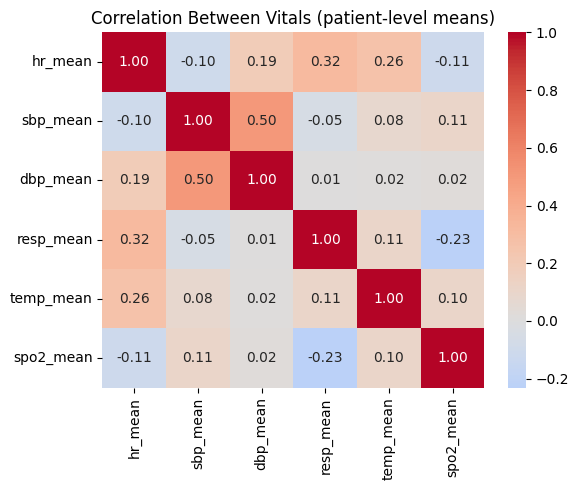

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

vital_agg_cols = ['hr_mean','sbp_mean','dbp_mean','resp_mean','temp_mean','spo2_mean']
corr = agg[vital_agg_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Between Vitals (patient-level means)')
plt.tight_layout()
plt.savefig('vitals_correlation.png', dpi=150)
plt.show()

## Lab Results (LABEVENTS)

In [20]:
sql_lab_freq = """
SELECT dl.label, le.itemid, COUNT(*) as n_readings, COUNT(DISTINCT le.hadm_id) as n_patients
FROM `physionet-data.mimiciii_clinical.labevents` le
JOIN `physionet-data.mimiciii_clinical.d_labitems` dl ON le.itemid = dl.itemid
WHERE le.hadm_id IN UNNEST(@hadm_ids)
  AND le.valuenum IS NOT NULL
GROUP BY dl.label, le.itemid
ORDER BY n_patients DESC
LIMIT 30
"""

hadm_ids = patients_df["hadm_id"].tolist()
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)]
)

lab_freq_df = client.query(sql_lab_freq, job_config=job_config).to_dataframe()
lab_freq_df

,label,itemid,n_readings,n_patients
0,Hematocrit,51221,492727,36108
1,Creatinine,50912,441898,36101
2,Urea Nitrogen,51006,440174,36101
3,Platelet Count,51265,424614,36097
4,White Blood Cells,51301,408444,36088
5,Hemoglobin,51222,408228,36082
6,MCHC,51249,405505,36081
7,MCH,51248,405282,36080
8,Red Blood Cells,51279,405288,36080
9,MCV,51250,405278,36080


In [21]:
lab_ids = [50931, 50912, 51301, 51222, 51265, 50983, 50971, 50813, 50882, 51221, 51006]

sql_lab_check = """
SELECT itemid, label, fluid, category
FROM `physionet-data.mimiciii_clinical.d_labitems`
WHERE itemid IN UNNEST(@lab_ids)
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("lab_ids", "INT64", lab_ids)]
)

lab_check_df = client.query(sql_lab_check, job_config=job_config).to_dataframe()
lab_check_df

,itemid,label,fluid,category
0,50813,Lactate,Blood,Blood Gas
1,50882,Bicarbonate,Blood,Chemistry
2,50912,Creatinine,Blood,Chemistry
3,50931,Glucose,Blood,Chemistry
4,50971,Potassium,Blood,Chemistry
5,50983,Sodium,Blood,Chemistry
6,51006,Urea Nitrogen,Blood,Chemistry
7,51221,Hematocrit,Blood,Hematology
8,51265,Platelet Count,Blood,Hematology
9,51301,White Blood Cells,Blood,Hematology


In [22]:
sql_labs = """
SELECT
  le.subject_id, le.hadm_id, le.charttime, le.itemid, le.valuenum, dl.label AS item_label
FROM `physionet-data.mimiciii_clinical.labevents` le
JOIN `physionet-data.mimiciii_clinical.d_labitems` dl ON le.itemid = dl.itemid
WHERE le.itemid IN UNNEST(@lab_ids)
  AND le.valuenum IS NOT NULL
  AND le.hadm_id IN UNNEST(@hadm_ids)
"""

hadm_ids = patients_df["hadm_id"].tolist()

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("lab_ids", "INT64", lab_ids),
        bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)
    ]
)

labs_df = client.query(sql_labs, job_config=job_config).to_dataframe()
print("lab rows extracted:", len(labs_df))
labs_df.to_csv(f'{save_dir}/labs_raw.csv', index=False)

lab rows extracted: 4515187


In [23]:
print(labs_df.groupby('item_label')['valuenum'].describe())

                      count        mean         std   min    25%    50%  \
item_label                                                                
Bicarbonate        429385.0   25.236898    4.796991   2.0   22.0   25.0   
Creatinine         441898.0    1.422062    1.921176   0.0    0.7    0.9   
Glucose            423456.0  132.296250   63.740257   1.0  100.0  119.0   
Hematocrit         492727.0   30.594031    5.146673   0.0   27.1   30.0   
Hemoglobin         408228.0   10.416906    1.831171   0.0    9.1   10.2   
Lactate            131076.0    2.663484    2.600978   0.0    1.2    1.8   
Platelet Count     424614.0  236.428283  154.340759   4.0  132.0  208.0   
Potassium          467969.0    4.091698    0.611216   0.8    3.7    4.0   
Sodium             447216.0  138.649731    5.078546  74.0  136.0  139.0   
Urea Nitrogen      440174.0   28.537745   23.141547   0.0   13.0   21.0   
White Blood Cells  408444.0   11.450186    8.858263   0.0    7.3   10.1   

                     75%

In [24]:
lab_plausible_ranges = {
    'Bicarbonate': (5, 60),
    'Creatinine': (0.1, 30),
    'Glucose': (10, 2000),
    'Hematocrit': (5, 65),
    'Hemoglobin': (1, 25),
    'Lactate': (0.1, 30),
    'Platelet Count': (2, 2500),
    'Potassium': (1.5, 10),
    'Sodium': (100, 180),
    'Urea Nitrogen': (1, 280),
    'White Blood Cells': (0.1, 300),
}

before = len(labs_df)
for lab, (lo, hi) in lab_plausible_ranges.items():
    mask = labs_df['item_label'] == lab
    bad = mask & ~labs_df['valuenum'].between(lo, hi)
    labs_df = labs_df[~bad]

print(f"dropped {before - len(labs_df)} implausible lab readings out of {before}")

dropped 194 implausible lab readings out of 4515187


In [25]:
labs_df['charttime'] = pd.to_datetime(labs_df['charttime'])

# bring in ICU intime so we can window to first 48h
intime_lookup = patients_df.set_index('hadm_id')['intime'].to_dict()
labs_df['intime'] = labs_df['hadm_id'].map(intime_lookup)
labs_df['intime'] = pd.to_datetime(labs_df['intime'])
labs_df['hours_from_admission'] = (labs_df['charttime'] - labs_df['intime']).dt.total_seconds() / 3600

labs_df_48h = labs_df[labs_df['hours_from_admission'].between(0, 48)]

labs_pivot = labs_df_48h.pivot_table(
    index='hadm_id', columns='item_label', values='valuenum', aggfunc=['mean', 'min', 'max']
)
labs_pivot.columns = ['_'.join(col).strip().lower().replace(' ', '_') for col in labs_pivot.columns]
labs_pivot = labs_pivot.reset_index()

print("labs summary shape:", labs_pivot.shape)
labs_pivot.to_csv(f'{save_dir}/labs_summary.csv', index=False)
labs_pivot.head()

labs summary shape: (35756, 34)


,hadm_id,mean_bicarbonate,mean_creatinine,mean_glucose,mean_hematocrit,mean_hemoglobin,mean_lactate,mean_platelet_count,mean_potassium,mean_sodium,...,max_creatinine,max_glucose,max_hematocrit,max_hemoglobin,max_lactate,max_platelet_count,max_potassium,max_sodium,max_urea_nitrogen,max_white_blood_cells
0,100001,19.857143,2.200000,166.571429,32.333333,11.166667,NaN,387.000000,3.900000,142.142857,...,2.4,264.0,32.8,11.3,NaN,407.0,4.4,145.0,42.0,15.9
1,100003,16.333333,1.100000,101.333333,28.057143,9.275000,1.1,151.000000,4.766667,133.000000,...,1.2,135.0,31.8,10.4,1.1,162.0,5.0,133.0,49.0,14.2
2,100006,25.000000,0.650000,130.000000,30.500000,10.250000,4.5,194.500000,4.050000,131.000000,...,0.7,131.0,30.6,10.3,4.5,204.0,4.4,131.0,16.0,16.6
3,100007,26.000000,0.666667,132.666667,33.500000,11.133333,NaN,209.000000,4.366667,138.000000,...,0.7,146.0,37.1,12.3,NaN,259.0,4.7,140.0,14.0,12.3
4,100009,23.500000,0.800000,173.500000,37.600000,12.966667,1.3,139.333333,4.266667,140.000000,...,0.8,177.0,39.9,13.7,1.5,149.0,4.4,143.0,13.0,17.3


In [26]:
n_lactate = labs_df[labs_df['item_label'] == 'Lactate']['hadm_id'].nunique()
print(f"Lactate coverage: {n_lactate} / {len(patients_df)} = {100*n_lactate/len(patients_df):.2f}%")

Lactate coverage: 24448 / 36515 = 66.95%


## Baseline 1: Logistic Regression (vitals + demographics)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

model_df = patients_df.merge(agg, on='icustay_id', how='inner')

feature_cols = ['age','hr_mean','hr_min','hr_max','sbp_mean','sbp_min','sbp_max',
                 'dbp_mean','dbp_min','dbp_max','resp_mean','resp_min','resp_max',
                 'temp_mean','temp_min','temp_max','spo2_mean','spo2_min','spo2_max',
                 'map_mean','map_min','map_max']

model_df = model_df.dropna(subset=feature_cols)

X = model_df[feature_cols]
y = model_df['mortality_label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg.fit(X_train_s, y_train)

probs = logreg.predict_proba(X_test_s)[:, 1]
print("AUROC:", roc_auc_score(y_test, probs))
print("AUPRC:", average_precision_score(y_test, probs))
print("patients used in model:", len(model_df))

AUROC: 0.7875550435227855
AUPRC: 0.40888649741055116
patients used in model: 35219


In [28]:
model_df_labs2 = patients_df.merge(agg, on='icustay_id', how='inner')

model_df_labs2 = model_df_labs2.dropna(subset=feature_cols)

model_df_labs2 = model_df_labs2.merge(labs_pivot, on='hadm_id', how='left')

lab_feature_cols = [c for c in labs_pivot.columns if c != 'hadm_id']
feature_cols_with_labs = feature_cols + lab_feature_cols

for col in lab_feature_cols:
    median_val = model_df_labs2[col].median()
    model_df_labs2[col] = model_df_labs2[col].fillna(median_val if pd.notna(median_val) else 0)

X_labs2 = model_df_labs2[feature_cols_with_labs]
y_labs2 = model_df_labs2['mortality_label']

X_train_l2, X_temp_l2, y_train_l2, y_temp_l2 = train_test_split(
    X_labs2, y_labs2, test_size=0.2, stratify=y_labs2, random_state=42
)
X_val_l2, X_test_l2, y_val_l2, y_test_l2 = train_test_split(
    X_temp_l2, y_temp_l2, test_size=0.5, stratify=y_temp_l2, random_state=42
)

scaler_l2 = StandardScaler()
X_train_l2_s = scaler_l2.fit_transform(X_train_l2)
X_test_l2_s = scaler_l2.transform(X_test_l2)

logreg_labs2 = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_labs2.fit(X_train_l2_s, y_train_l2)

probs_labs2 = logreg_labs2.predict_proba(X_test_l2_s)[:, 1]
print("AUROC (full cohort, labs median-filled):", roc_auc_score(y_test_l2, probs_labs2))
print("AUPRC (full cohort, labs median-filled):", average_precision_score(y_test_l2, probs_labs2))
print("patients used:", len(model_df_labs2))

AUROC (full cohort, labs median-filled): 0.845616146100017
AUPRC (full cohort, labs median-filled): 0.5003774241951423
patients used: 35219


In [29]:
coefs_labs = pd.Series(logreg_labs2.coef_[0], index=feature_cols_with_labs).sort_values(ascending=False)
print("top 15 positive coefficients (associated with death):")
print(coefs_labs.head(15))

top 15 positive coefficients (associated with death):
min_hematocrit           0.878957
min_urea_nitrogen        0.750079
mean_sodium              0.513430
mean_glucose             0.496022
age                      0.390814
min_white_blood_cells    0.357630
max_lactate              0.324565
min_lactate              0.301947
temp_max                 0.289417
hr_mean                  0.288317
max_hemoglobin           0.274433
hr_max                   0.229008
sbp_max                  0.215485
resp_min                 0.214332
dbp_min                  0.189768
dtype: float64


In [30]:
print("mortality rate, full cohort:", patients_df['mortality_label'].mean())
print("mortality rate, patients with labs (median-filled):", model_df_labs2['mortality_label'].mean())

mortality rate, full cohort: 0.10817472271669178
mortality rate, patients with labs (median-filled): 0.1057667736165138


## Discrete Events: windowed (first 48h), leakage-safe extraction

In [31]:
sql_procedures_windowed = """
SELECT
  p.subject_id, p.hadm_id, p.icustay_id, p.itemid, di.label AS item_label,
  DATETIME_DIFF(p.starttime, ic.intime, HOUR) AS hours_from_admission
FROM `physionet-data.mimiciii_clinical.procedureevents_mv` p
JOIN `physionet-data.mimiciii_clinical.d_items` di ON p.itemid = di.itemid
JOIN `physionet-data.mimiciii_clinical.icustays` ic ON p.icustay_id = ic.icustay_id
WHERE p.icustay_id IN UNNEST(@stay_ids)
  AND DATETIME_DIFF(p.starttime, ic.intime, HOUR) BETWEEN 0 AND 48
"""

sql_prescriptions_windowed = """
SELECT
  pr.subject_id, pr.hadm_id, pr.icustay_id, pr.drug,
  DATETIME_DIFF(pr.startdate, ic.intime, HOUR) AS hours_from_admission
FROM `physionet-data.mimiciii_clinical.prescriptions` pr
JOIN `physionet-data.mimiciii_clinical.icustays` ic ON pr.icustay_id = ic.icustay_id
WHERE pr.icustay_id IN UNNEST(@stay_ids)
  AND DATETIME_DIFF(pr.startdate, ic.intime, HOUR) BETWEEN 0 AND 48
"""

stay_ids = patients_df["icustay_id"].tolist()
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("stay_ids", "INT64", stay_ids)]
)

procedures_windowed_df = client.query(sql_procedures_windowed, job_config=job_config).to_dataframe()
prescriptions_windowed_df = client.query(sql_prescriptions_windowed, job_config=job_config).to_dataframe()

print("procedures (first 48h):", len(procedures_windowed_df))
print("prescriptions (first 48h):", len(prescriptions_windowed_df))

procedures (first 48h): 121073
prescriptions (first 48h): 779762


In [32]:
TOP_N = 100

top_procedures_w = procedures_windowed_df['item_label'].value_counts().head(TOP_N).index
top_drugs_w = prescriptions_windowed_df['drug'].value_counts().head(TOP_N).index

proc_filtered_w = procedures_windowed_df[procedures_windowed_df['item_label'].isin(top_procedures_w)]
drug_filtered_w = prescriptions_windowed_df[prescriptions_windowed_df['drug'].isin(top_drugs_w)]

proc_wide_w = pd.crosstab(proc_filtered_w['hadm_id'], proc_filtered_w['item_label'])
proc_wide_w = (proc_wide_w > 0).astype(int)
proc_wide_w.columns = ['proc_' + c for c in proc_wide_w.columns]

drug_wide_w = pd.crosstab(drug_filtered_w['hadm_id'], drug_filtered_w['drug'])
drug_wide_w = (drug_wide_w > 0).astype(int)
drug_wide_w.columns = ['drug_' + c for c in drug_wide_w.columns]

events_windowed_df = proc_wide_w.join(drug_wide_w, how='outer')
events_windowed_df = events_windowed_df.fillna(0).astype(int)
events_windowed_df = events_windowed_df.reset_index()

print("windowed discrete events shape:", events_windowed_df.shape)
events_windowed_df.to_csv(f'{save_dir}/discrete_events_windowed.csv', index=False)
print("saved")

windowed discrete events shape: (32536, 201)
saved


### Sensitivity check: windowed events before removing outcome-adjacent codes (preliminary)

In [33]:
model_df_events_w = patients_df.merge(events_windowed_df, on='hadm_id', how='inner')
feature_cols_events_w = [c for c in events_windowed_df.columns if c != 'hadm_id']

X_ev_w = model_df_events_w[feature_cols_events_w]
y_ev_w = model_df_events_w['mortality_label']

X_train_ev_w, X_temp_ev_w, y_train_ev_w, y_temp_ev_w = train_test_split(
    X_ev_w, y_ev_w, test_size=0.2, stratify=y_ev_w, random_state=42
)
X_val_ev_w, X_test_ev_w, y_val_ev_w, y_test_ev_w = train_test_split(
    X_temp_ev_w, y_temp_ev_w, test_size=0.5, stratify=y_temp_ev_w, random_state=42
)


logreg_ev_w = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_ev_w.fit(X_train_ev_w, y_train_ev_w)

probs_ev_w = logreg_ev_w.predict_proba(X_test_ev_w)[:, 1]
print("Windowed discrete events AUROC:", roc_auc_score(y_test_ev_w, probs_ev_w))
print("Windowed discrete events AUPRC:", average_precision_score(y_test_ev_w, probs_ev_w))
print("patients used:", len(model_df_events_w))

Windowed discrete events AUROC: 0.8389375358871299
Windowed discrete events AUPRC: 0.4131376890338102
patients used: 32533


### Final discrete-events feature set: windowed + outcome-adjacent codes removed
Final discrete-events feature set used for modelling.

In [34]:
outcome_events_v2 = ['Cardiac Arrest', 'Brain Death', 'NEOB notified', 'Respiratory Arrest', 'Family meeting held']

procedures_final = procedures_windowed_df[~procedures_windowed_df['item_label'].isin(outcome_events_v2)]

top_procedures_final = procedures_final['item_label'].value_counts().head(100).index
proc_filtered_final = procedures_final[procedures_final['item_label'].isin(top_procedures_final)]

proc_wide_final = pd.crosstab(proc_filtered_final['hadm_id'], proc_filtered_final['item_label'])
proc_wide_final = (proc_wide_final > 0).astype(int)
proc_wide_final.columns = ['proc_' + c for c in proc_wide_final.columns]

events_final_df = proc_wide_final.join(drug_wide_w, how='outer')
events_final_df = events_final_df.fillna(0).astype(int).reset_index()

model_df_final = patients_df.merge(events_final_df, on='hadm_id', how='inner')
feature_cols_final = [c for c in events_final_df.columns if c != 'hadm_id']

X_final = model_df_final[feature_cols_final]
y_final = model_df_final['mortality_label']

X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)
X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_temp_f, y_temp_f, test_size=0.5, stratify=y_temp_f, random_state=42
)

logreg_final = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_final.fit(X_train_f, y_train_f)

probs_final = logreg_final.predict_proba(X_test_f)[:, 1]
print("Final discrete events AUROC:", roc_auc_score(y_test_f, probs_final))
print("Final discrete events AUPRC:", average_precision_score(y_test_f, probs_final))

coefs_final = pd.Series(logreg_final.coef_[0], index=feature_cols_final).sort_values(ascending=False)
print("\ntop 15 coefficients:")
print(coefs_final.head(15))

Final discrete events AUROC: 0.8467568288081372
Final discrete events AUPRC: 0.415295016983995

top 15 coefficients:
proc_Triple Introducer                  1.885274
proc_Intraventricular Drain Inserted    1.586636
proc_Intraosseous Device                1.561666
proc_Radiation Therapy                  1.513723
proc_Paracentesis                       1.412081
proc_Invasive Ventilation               1.296584
proc_Drain Removed                      1.147694
proc_Trauma line                        1.011661
drug_Morphine Sulfate                   0.961307
drug_D5W                                0.906668
proc_Percutaneous Drain Insertion       0.821410
proc_Indwelling Port (PortaCath)        0.817411
proc_Nuclear Medicine                   0.813466
drug_Soln.                              0.792206
proc_Family updated by MD               0.770586
dtype: float64


In [35]:
events_final_df.to_csv(f'{save_dir}/discrete_events_final.csv', index=False)
print("saved")

saved


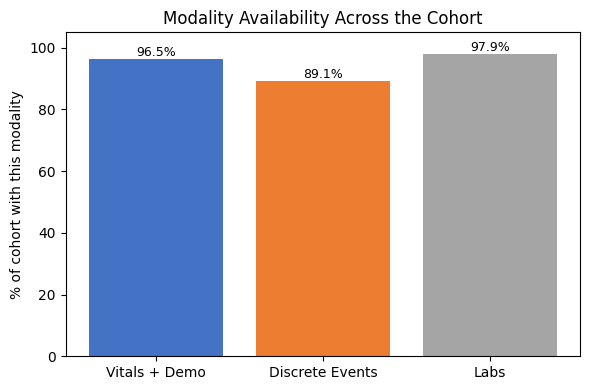

In [36]:
n_total = len(patients_df)
n_vitals = model_df['icustay_id'].nunique()
n_events = model_df_final['icustay_id'].nunique() if 'icustay_id' in model_df_final else len(model_df_final)
n_labs = labs_pivot['hadm_id'].nunique()  # adjust based on your actual labs dataframe

availability = pd.Series({
    'Vitals + Demo': n_vitals / n_total * 100,
    'Discrete Events': n_events / n_total * 100,
    'Labs': n_labs / n_total * 100,
})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(availability.index, availability.values, color=['#4472C4', '#ED7D31', '#A5A5A5'])
ax.set_ylabel('% of cohort with this modality')
ax.set_ylim(0, 105)
ax.set_title('Modality Availability Across the Cohort')
for bar, v in zip(bars, availability.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figure_5_modality_availability.png', dpi=150)
plt.show()

## Baseline 2: LSTM on hourly vitals sequences

Build padded sequences from the hourly table

In [37]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

vital_cols = ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'temp_c', 'spo2', 'map']

hourly_sorted = hourly.sort_values(['icustay_id', 'hour'])

# to their first 48 hours
MAX_HOURS = 48

sequences = []
labels = []
stay_ids_used = []

label_lookup = patients_df.set_index('icustay_id')['mortality_label'].to_dict()

for stay_id, group in hourly_sorted.groupby('icustay_id'):
    if stay_id not in label_lookup:
        continue
    vals = group[vital_cols].values[:MAX_HOURS]
    if np.isnan(vals).all():
        continue
    col_means = np.nanmean(vals, axis=0)
    col_means = np.nan_to_num(col_means, nan=0.0)
    inds = np.where(np.isnan(vals))
    vals[inds] = np.take(col_means, inds[1])

    sequences.append(vals)
    labels.append(label_lookup[stay_id])
    stay_ids_used.append(stay_id)

print("sequences built:", len(sequences))
print("mortality rate in this set:", np.mean(labels))

/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanme

sequences built: 35992
mortality rate in this set: 0.10810735719048678


/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)
/tmp/ipykernel_1047/3142114506.py:27: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(vals, axis=0)


In [38]:
lengths = [len(s) for s in sequences]
max_len = max(lengths)

X_seq = np.zeros((len(sequences), max_len, len(vital_cols)), dtype=np.float32)
for i, s in enumerate(sequences):
    X_seq[i, :len(s), :] = s

y_seq = np.array(labels, dtype=np.float32)
lengths = np.array(lengths)

# normalize using train stats only (fit after split, to avoid leakage)
X_train_lstm, X_temp_lstm, y_train_lstm, y_temp_lstm, len_train, len_temp = train_test_split(
    X_seq, y_seq, lengths, test_size=0.2, stratify=y_seq, random_state=42
)
X_val_lstm, X_test_lstm, y_val_lstm, y_test_lstm, len_val, len_test = train_test_split(
    X_temp_lstm, y_temp_lstm, len_temp, test_size=0.5, stratify=y_temp_lstm, random_state=42
)

train_mean = X_train_lstm.reshape(-1, X_train_lstm.shape[-1]).mean(axis=0)
train_std = X_train_lstm.reshape(-1, X_train_lstm.shape[-1]).std(axis=0) + 1e-6

X_train_lstm = (X_train_lstm - train_mean) / train_std
X_test_lstm = (X_test_lstm - train_mean) / train_std

class ICUDataset(Dataset):
    def __init__(self, X, y, lengths):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]

train_ds = ICUDataset(X_train_lstm, y_train_lstm, len_train)
test_ds = ICUDataset(X_test_lstm, y_test_lstm, len_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("train size:", len(train_ds), "test size:", len(test_ds))

train size: 28793 test size: 3600


In [39]:
import numpy as np

hourly.to_csv(f'{save_dir}/vitals_hourly_processed.csv', index=False)

np.savez(
    f'{save_dir}/vitals_sequences.npz',
    X_seq=X_seq,
    y_seq=y_seq,
    lengths=lengths,
    stay_ids_used=np.array(stay_ids_used)
)

agg.to_csv(f'{save_dir}/vitals_agg.csv', index=False)

print("saved: vitals_hourly_processed.csv, vitals_sequences.npz, vitals_agg.csv")

saved: vitals_hourly_processed.csv, vitals_sequences.npz, vitals_agg.csv


In [40]:
class VitalsLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        out = self.fc(h_n[-1])
        return out.squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("using device:", device)

model = VitalsLSTM().to(device)

pos_weight = torch.tensor([(len(y_train_lstm) - y_train_lstm.sum()) / y_train_lstm.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb, lb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb, lb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}/{EPOCHS}  loss: {total_loss/len(train_loader):.4f}")

using device: cpu
epoch 1/10  loss: 1.1263
epoch 2/10  loss: 1.0851
epoch 3/10  loss: 1.0833
epoch 4/10  loss: 1.0534
epoch 5/10  loss: 1.0450
epoch 6/10  loss: 1.0381
epoch 7/10  loss: 1.0250
epoch 8/10  loss: 1.0336
epoch 9/10  loss: 1.0332
epoch 10/10  loss: 1.0216


In [41]:
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb, lb in test_loader:
        xb = xb.to(device)
        logits = model(xb, lb)
        batch_probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(batch_probs)
        all_labels.extend(yb.numpy())

print("LSTM AUROC:", roc_auc_score(all_labels, all_probs))
print("LSTM AUPRC:", average_precision_score(all_labels, all_probs))
print("patients used:", len(all_labels))

LSTM AUROC: 0.7396149482939031
LSTM AUPRC: 0.4046907666876449
patients used: 3600


### LSTM diagnostics

In [42]:
print("sequence length distribution (hours, capped at 48):")
print(pd.Series(lengths).describe())

sequence length distribution (hours, capped at 48):
count    35992.000000
mean        37.825795
std         12.442875
min          1.000000
25%         26.000000
50%         47.000000
75%         48.000000
max         48.000000
dtype: float64


Missing values filled by per-patient mean imputation.

In [43]:
nan_count = sum(np.isnan(s).sum() for s in [group[vital_cols].values[:MAX_HOURS]
                for stay_id, group in hourly_sorted.groupby('icustay_id')])
total_count = sum(s.size for s in sequences)
print(f"missing values filled: {nan_count} / {total_count} ({100*nan_count/total_count:.1f}%)")

missing values filled: 127754 / 9529982 (1.3%)


LSTM performance by ICU stay length.

In [44]:
short_mask = len_test <= 12
long_mask = len_test > 12

from sklearn.metrics import roc_auc_score
probs_arr = np.array(all_probs)
labels_arr = np.array(all_labels)

print("AUROC (stays <=12h):", roc_auc_score(labels_arr[short_mask.numpy() if hasattr(short_mask,'numpy') else short_mask], probs_arr[short_mask.numpy() if hasattr(short_mask,'numpy') else short_mask]))
print("AUROC (stays >12h):", roc_auc_score(labels_arr[long_mask.numpy() if hasattr(long_mask,'numpy') else long_mask], probs_arr[long_mask.numpy() if hasattr(long_mask,'numpy') else long_mask]))

AUROC (stays <=12h): 0.9247159090909091
AUROC (stays >12h): 0.7130155282775936


## Baseline 3: Logistic Regression (discrete events, windowed) — preliminary

In [45]:
X_train_ev_w2, X_test_ev_w2, y_train_ev_w2, y_test_ev_w2 = X_train_f, X_test_f, y_train_f, y_test_f
probs_ev_final = probs_final
print("Final discrete events AUROC:", roc_auc_score(y_test_f, probs_final))
print("Final discrete events AUPRC:", average_precision_score(y_test_f, probs_final))


Final discrete events AUROC: 0.8467568288081372
Final discrete events AUPRC: 0.415295016983995


## Baseline 4: Logistic Regression (labs only)

In [46]:
model_df_labs = patients_df.merge(labs_pivot, on='hadm_id', how='inner')
lab_feature_cols = [c for c in labs_pivot.columns if c != 'hadm_id']
model_df_labs = model_df_labs.dropna(subset=lab_feature_cols, thresh=len(lab_feature_cols)//2)  # keep patients with at least half the labs
for col in lab_feature_cols:
    model_df_labs[col] = model_df_labs[col].fillna(model_df_labs[col].median())

X_labs = model_df_labs[lab_feature_cols]
y_labs = model_df_labs['mortality_label']

X_train_labs, X_temp_labs, y_train_labs, y_temp_labs = train_test_split(
    X_labs, y_labs, test_size=0.2, stratify=y_labs, random_state=42
)
X_val_labs, X_test_labs, y_val_labs, y_test_labs = train_test_split(
    X_temp_labs, y_temp_labs, test_size=0.5, stratify=y_temp_labs, random_state=42
)

scaler_labs = StandardScaler()
X_train_labs_s = scaler_labs.fit_transform(X_train_labs)
X_test_labs_s = scaler_labs.transform(X_test_labs)

logreg_labs = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_labs.fit(X_train_labs_s, y_train_labs)

probs_labs = logreg_labs.predict_proba(X_test_labs_s)[:, 1]
print("Labs-only AUROC:", roc_auc_score(y_test_labs, probs_labs))
print("Labs-only AUPRC:", average_precision_score(y_test_labs, probs_labs))

Labs-only AUROC: 0.7943748194708502
Labs-only AUPRC: 0.4212787952995273


## Comparison chart across unimodal baselines


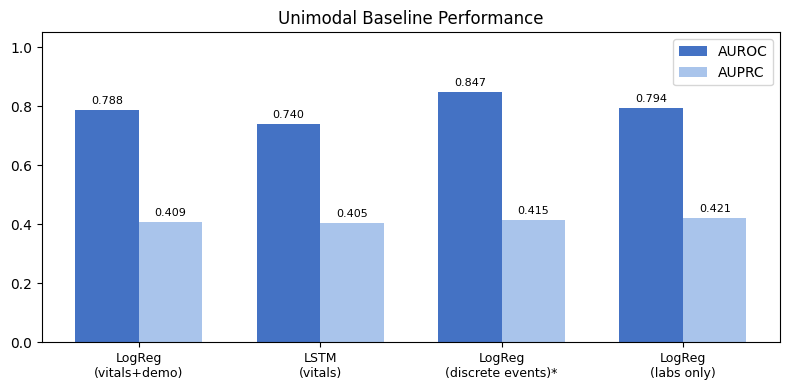

In [47]:
import matplotlib.pyplot as plt
import numpy as np

models = ['LogReg\n(vitals+demo)', 'LSTM\n(vitals)', 'LogReg\n(discrete events)*', 'LogReg\n(labs only)']
auroc_scores = [
    roc_auc_score(y_test, probs),
    roc_auc_score(all_labels, all_probs),
    roc_auc_score(y_test_f, probs_final),
    roc_auc_score(y_test_labs, probs_labs)
]
auprc_scores = [
    average_precision_score(y_test, probs),
    average_precision_score(all_labels, all_probs),
    average_precision_score(y_test_f, probs_final),
    average_precision_score(y_test_labs, probs_labs)
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - width/2, auroc_scores, width, label='AUROC', color='#4472C4')
b2 = ax.bar(x + width/2, auprc_scores, width, label='AUPRC', color='#A9C4EB')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title('Unimodal Baseline Performance')
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

ROC curves for unimodal baselines

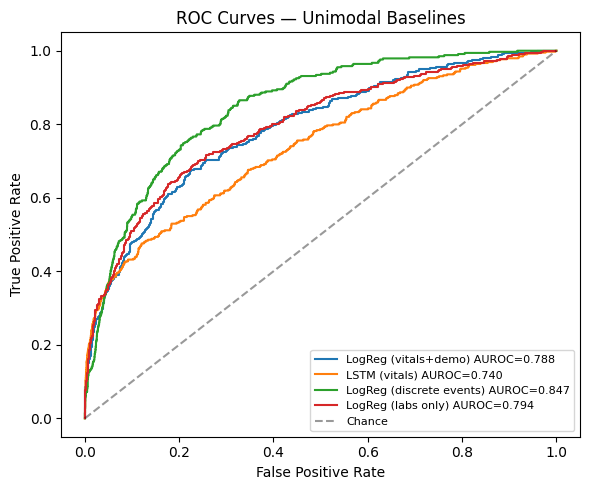

In [48]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 5))

fpr1, tpr1, _ = roc_curve(y_test, probs)
ax.plot(fpr1, tpr1, label=f'LogReg (vitals+demo) AUROC={roc_auc_score(y_test, probs):.3f}')

fpr2, tpr2, _ = roc_curve(all_labels, all_probs)
ax.plot(fpr2, tpr2, label=f'LSTM (vitals) AUROC={roc_auc_score(all_labels, all_probs):.3f}')

fpr3, tpr3, _ = roc_curve(y_test_f, probs_final)
ax.plot(fpr3, tpr3, label=f'LogReg (discrete events) AUROC={roc_auc_score(y_test_f, probs_final):.3f}')

fpr4, tpr4, _ = roc_curve(y_test_labs, probs_labs)
ax.plot(fpr4, tpr4, label=f'LogReg (labs only) AUROC={roc_auc_score(y_test_labs, probs_labs):.3f}')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Unimodal Baselines')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('chart_roc_curves.png', dpi=150)
plt.show()

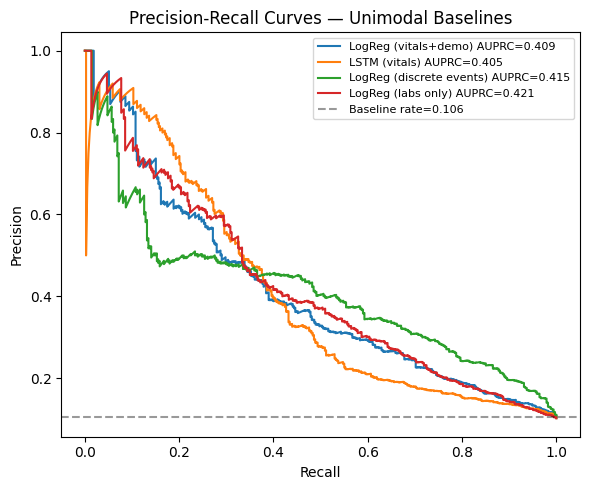

In [49]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(6, 5))

p1, r1, _ = precision_recall_curve(y_test, probs)
ax.plot(r1, p1, label=f'LogReg (vitals+demo) AUPRC={average_precision_score(y_test, probs):.3f}')

p2, r2, _ = precision_recall_curve(all_labels, all_probs)
ax.plot(r2, p2, label=f'LSTM (vitals) AUPRC={average_precision_score(all_labels, all_probs):.3f}')

p3, r3, _ = precision_recall_curve(y_test_f, probs_final)
ax.plot(r3, p3, label=f'LogReg (discrete events) AUPRC={average_precision_score(y_test_f, probs_final):.3f}')

p4, r4, _ = precision_recall_curve(y_test_labs, probs_labs)
ax.plot(r4, p4, label=f'LogReg (labs only) AUPRC={average_precision_score(y_test_labs, probs_labs):.3f}')

baseline_rate = np.mean(y_test)
ax.axhline(baseline_rate, color='k', linestyle='--', alpha=0.4, label=f'Baseline rate={baseline_rate:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Unimodal Baselines')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

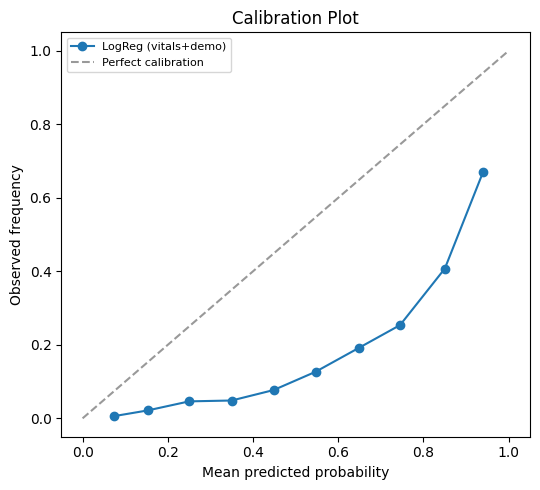

In [50]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(mean_pred, frac_pos, marker='o', label='LogReg (vitals+demo)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Calibration Plot')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

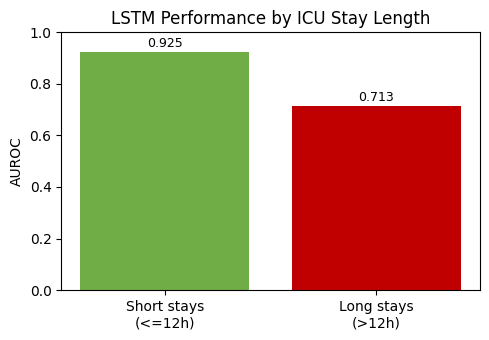

In [51]:
short_mask = (len_test <= 12).numpy() if hasattr(len_test, 'numpy') else (len_test <= 12)
long_mask = (len_test > 12).numpy() if hasattr(len_test, 'numpy') else (len_test > 12)

probs_arr = np.array(all_probs)
labels_arr = np.array(all_labels)

auroc_short = roc_auc_score(labels_arr[short_mask], probs_arr[short_mask])
auroc_long = roc_auc_score(labels_arr[long_mask], probs_arr[long_mask])

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Short stays\n(<=12h)', 'Long stays\n(>12h)'], [auroc_short, auroc_long],
              color=['#70AD47', '#C00000'])
ax.set_ylabel('AUROC')
ax.set_ylim(0, 1.0)
ax.set_title('LSTM Performance by ICU Stay Length')
for bar, v in zip(bars, [auroc_short, auroc_long]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()